# Assignment 3: Linear Models

In [1]:
! git clone https://github.com/lydialeelee/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear when the parameters/coefficients are linear, not the variables. In other words, the predicted output is a weighted sum of the coefficients.
2. A dummy variable coefficient represents the average difference in the dependent variable (y) when the categorical variable is 1 compared to the reference group (where the dummy is 0).
3. You could fit a linear regression to a binary outcome, either 0 or 1, but it is not the smartest choice to make. One reason is that the predicted values are not bounded between 0 and 1, so they cannot be interpreted as probabilities. Another reason is the relationship between the binary outcome and predictors is inherently nonlinear, so a straight line can't capture the data well.
4. One sign is a large gap between training performance and test performance, specifically strong correlation coefficient on training data but a poor correlation coefficient on test data. Another sign could be coefficients that are unstable like they change so much depending on the observations.
5. Multicollinearity occurs when two or more predictors are highly correlated with each other. It makes it impossible for Ordinary Least Squares to figure out which y variable is causing the difference. Two-State Least Squares is when an x variable is too closely related to an error term. So then, you find a third variable that influences x, but has nothing tod o with the error term. Then you use the third variable to extract only the clean part of x. So, then you use this new version of x in the regression.
6. Since the model has to be linear in parameters, you incorporate nonlinearity through the features. You can transform the x variables before they enter the model like changing it to polynomial terms or logarithmic transformation. The model equations stay a linear combination of coefficients, but the features carry the nonlinear shape.
7. The slope coefficient on a variable x means that for every 1-unit increase in x, we expect y to change by beta1 units, holding all other variables constant. The interpretation of the slope coefficient is that only the x variables changes and everything else is frozen in place.
8. A train/test split breaks the data once, normally 70% for trianing and 30% for testing. The model is trained on one portion and evaluated on the other. This is much simpler, but it can be sensitive to which observations end up in each split.
k-fold cross validation is more difficult. The data is divided into k equal folds. The model is trained k times with each time using k-1 folds for training and the remaining fold as the validation set. The performance metrix is averages from all the k runs. This means that every observation gets to be in the validation set exactly once.
9. The most common are k=5 and k=10. Lower k values has high bias because the model doesn't see enough data. Higher k values have high variance. So k=10 usually provides a stable estimate of the true error rate.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

df = pd.read_csv('/content/Q1_clean.csv')
df = df.rename(columns={
    'Neighbourhood ': 'Neighbourhood',
    'Review Scores Rating': 'Review_Scores_Rating'
})

df.head()

,Price,Review_Scores_Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


                    Price  Review_Scores_Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


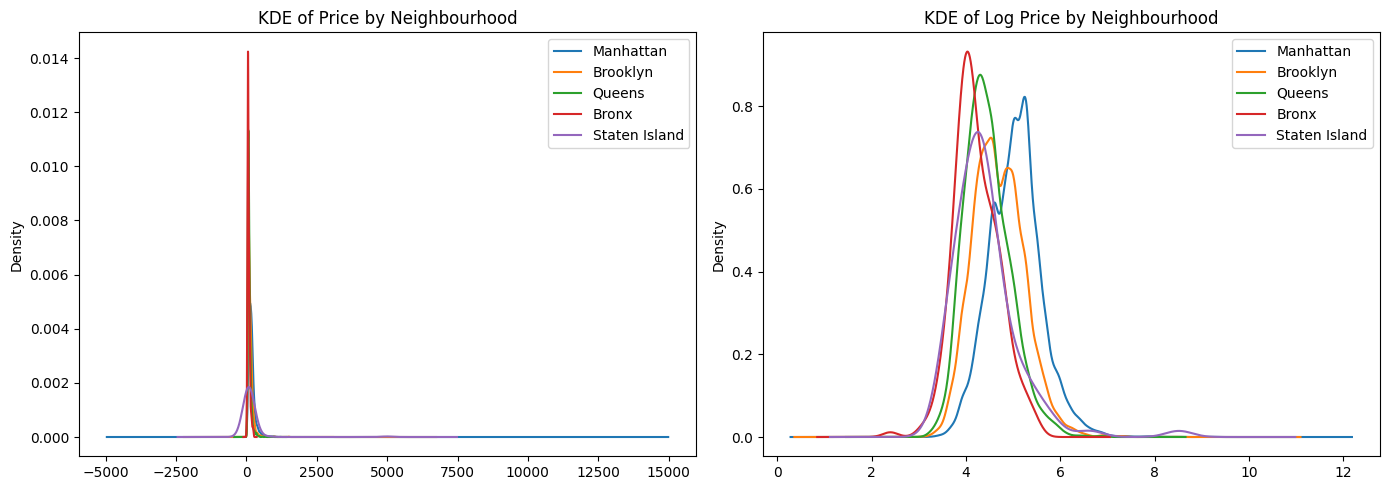

In [3]:
#1
grouped = df.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']].mean()
print(grouped.sort_values('Price', ascending=False))

# Kernel density plot of Price
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == n]
    subset['Price'].plot.kde(ax=axes[0], label=n)
    np.log(subset['Price']+1).plot.kde(ax=axes[1], label=n)

axes[0].set_title('KDE of Price by Neighbourhood')
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

Manhattan is the most expensive borough, followed by Staten Island, Brooklyn, Queens, and the Bronx.

In [4]:
#2
model2 = smf.ols('Price ~ C(Neighbourhood)', data=df).fit()
print(model2.summary())

# Compare to group means from part 1
print(grouped['Price'])

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        20:04:45   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

I drop the first category (Bronx) to avoid the dummy variable trap, including all 5 dummies would create perfect multicollinearity since they'd sum to 1. The intercept is Bronx mean price ($75.28). Each dummy coefficient tells you how much more expensive that borough is relative to the Bronx.

In [5]:
#3
model3 = smf.ols('Price ~ Review_Scores_Rating', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        20:04:45   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 

A one-point increase in Review Scores Rating is associated with a $1.02 increase in expected nightly price, holding everything else constant.

In [6]:
#4
model4 = smf.ols('Price ~ C(Neighbourhood) + Review_Scores_Rating', data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        20:04:45   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

The Review Score slope barely changes because it goes from $1.02 to 1.08. This means review scores and neighbourhood are not confounding each other.

The neighbourhood coefficients are almost identical. Tiny changes confirms that neighbourhood and review scores are largely independent of each other.

In [7]:
#5
model5 = smf.ols('Price ~ C(Neighbourhood) * Review_Scores_Rating', data=df).fit()
print(model5.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:04:46   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [8]:
cats = df["Neighbourhood"].astype("category").cat.categories.tolist()
base = cats[0]

slopes = {}
base_slope = model5.params["Review_Scores_Rating"]
slopes[base] = base_slope

for c in cats[1:]:
    term = f"C(Neighbourhood)[T.{c}]:Review_Scores_Rating"
    slopes[c] = base_slope + model5.params.get(term, 0)

pd.Series(slopes, name="review_score_slope_by_neighbourhood").sort_values()


,review_score_slope_by_neighbourhood
Staten Island,-31.257437
Queens,0.502017
Bronx,0.574311
Manhattan,1.304014
Brooklyn,1.315476


The slope between Manhattan and Brooklyn are similar and Bronx and Queens are also similar. Only Staten Island has an outlying slope.

In [9]:
#6
def rmse_cv_formula(formula, data, k=10):
    y = data["Price"].values
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
        fit = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse = np.sqrt(np.mean((test["Price"] - preds) ** 2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

cv_results_q2 = pd.DataFrame({
    "model": [
        "Price ~ Review_Scores_Rating",
        "Price ~ C(Neighbourhood) + Review_Scores_Rating",
        "Price ~ C(Neighbourhood) * Review_Scores_Rating"
    ],
    "mean_rmse": [
        rmse_cv_formula("Price ~ Review_Scores_Rating", df)[0],
        rmse_cv_formula("Price ~ C(Neighbourhood) + Review_Scores_Rating", df)[0],
        rmse_cv_formula("Price ~ C(Neighbourhood) * Review_Scores_Rating", df)[0]
    ],
    "sd_rmse": [
        rmse_cv_formula("Price ~ Review_Scores_Rating", df)[1],
        rmse_cv_formula("Price ~ C(Neighbourhood) + Review_Scores_Rating", df)[1],
        rmse_cv_formula("Price ~ C(Neighbourhood) * Review_Scores_Rating", df)[1]
    ]
}).sort_values("mean_rmse")

cv_results_q2

,model,mean_rmse,sd_rmse
1,Price ~ C(Neighbourhood) + Review_Scores_Rating,139.010186,41.796868
2,Price ~ C(Neighbourhood) * Review_Scores_Rating,139.999082,41.514037
0,Price ~ Review_Scores_Rating,142.759439,41.242175


The model with the lowest cross-validation RMSE is best out of sample predictor out of the three models.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


## Part 1

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold

df = pd.read_csv('/content/data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


=== Price Summary ===
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


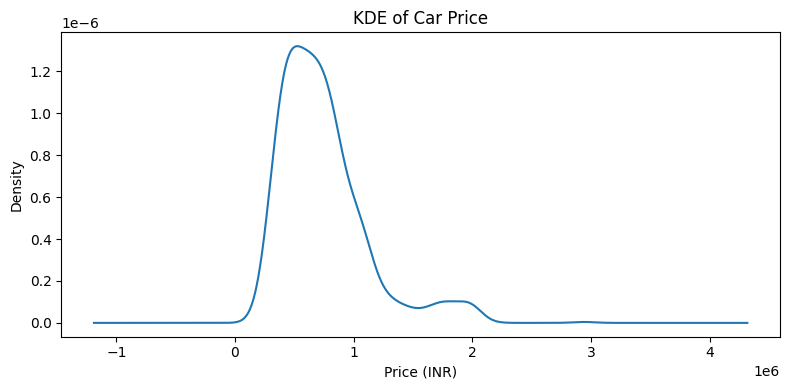

In [11]:
# Summarize Price overall
print('=== Price Summary ===')
print(df['Price'].describe())

# KDE of Price
fig, ax = plt.subplots(figsize=(8, 4))
df['Price'].plot.kde(ax=ax)
ax.set_title('KDE of Car Price')
ax.set_xlabel('Price (INR)')
plt.tight_layout()
plt.show()

In [12]:
# Summarize Price by Body_Type
print('=== Price by Body Type ===')
print(df.groupby('Body_Type')['Price'].describe().round(0))

=== Price by Body Type ===
           count       mean       std       min       25%        50%  \
Body_Type                                                              
crossover   21.0   705095.0   72850.0  608000.0  638000.0   706000.0   
hatchback  484.0   533977.0  173087.0  188000.0  401750.0   509000.0   
muv         38.0   626421.0  184093.0  328000.0  489750.0   621500.0   
sedan      227.0   809784.0  286737.0  368000.0  598000.0   772000.0   
suv        206.0  1176495.0  417479.0  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


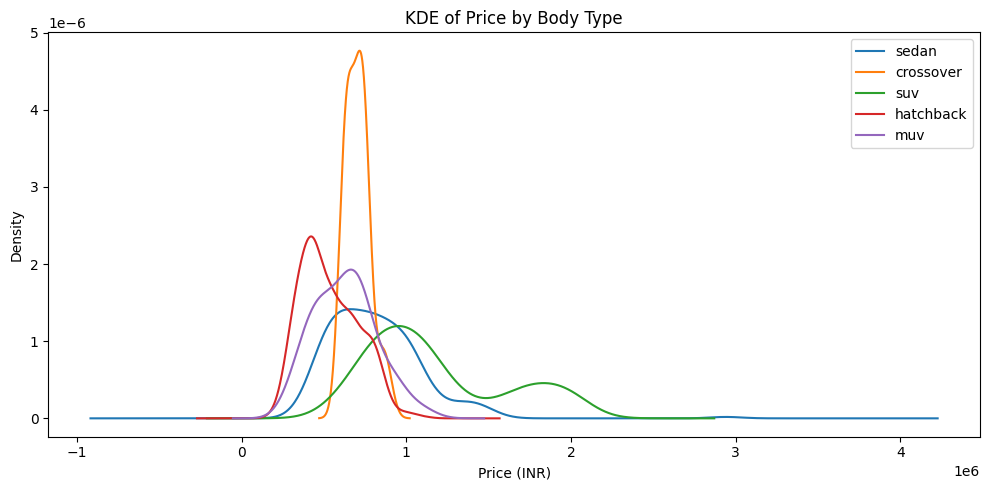

In [13]:
# Grouped KDE by Body_Type
fig, ax = plt.subplots(figsize=(10, 5))
for body in df['Body_Type'].unique():
    subset = df[df['Body_Type'] == body]
    subset['Price'].plot.kde(ax=ax, label=body)

ax.set_title('KDE of Price by Body Type')
ax.set_xlabel('Price (INR)')
ax.legend()
plt.tight_layout()
plt.show()

- SUVs are the most expensive body type on average and have the most variance.
- Hatchbacks are the cheapest and have the least variance.

## Part 2

In [14]:
X = sm.add_constant(df['Seating_Capacity'])
model_seats = sm.OLS(df['Price'], X).fit()
print(model_seats.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        20:04:57   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [15]:
slope = model_seats.params['Seating_Capacity']
print(f'Slope: {slope:,.0f}')
print(f'Interpretation: Each additional seat is associated with a {slope:,.0f} increase in expected price.')

Slope: 59,268
Interpretation: Each additional seat is associated with a 59,268 increase in expected price.


In [16]:
# Treat Seating_Capacity as categorical (one-hot encoded)
model_seats_cat = smf.ols('Price ~ C(Seating_Capacity)', data=df).fit()
print(model_seats_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000267
Time:                        20:04:57   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [17]:
# Compare group means to see if relationship is linear
print('Average price by Seating Capacity:')
print(df.groupby('Seating_Capacity')['Price'].mean().round(0))

Average price by Seating Capacity:
Seating_Capacity
4     188000.0
5     734484.0
6    1644000.0
7     923949.0
8     459800.0
Name: Price, dtype: float64


No, they are not linear. Looking at the slopes, they don't increase by the same amount. They actually decrease in price after the 6-seat vehicle.

## Part 3

In [18]:
# Create Age variable
df['Age'] = 2024 - df['Make_Year']
print('Age distribution:')
print(df['Age'].describe())

Age distribution:
count    976.000000
mean       7.036885
std        2.818742
min        2.000000
25%        5.000000
50%        7.000000
75%        9.000000
max       13.000000
Name: Age, dtype: float64


In [19]:
# 10-fold cross validation for different polynomial degrees
def rmse_cv(formula, data, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test  = data.iloc[test_idx]
        fit   = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse  = np.sqrt(np.mean((test['Price'] - preds)**2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

results = []
for p in range(1, 9):
    formula = 'Price ~ ' + ' + '.join([f'np.power(Age, {i})' for i in range(1, p+1)])
    mean_rmse, std_rmse = rmse_cv(formula, df)
    results.append({'powers': p, 'mean_rmse': mean_rmse, 'std_rmse': std_rmse})

cv_results = pd.DataFrame(results)
print(cv_results.to_string(index=False))
best = cv_results.loc[cv_results['mean_rmse'].idxmin()]
print(f'\nBest: {int(best.powers)} power(s) with RMSE = {best.mean_rmse:,.0f}')

 powers     mean_rmse     std_rmse
      1 310765.360714 28322.052262
      2 310779.295964 28494.476108
      3 309697.344638 28822.899617
      4 308871.567777 28694.823069
      5 307368.981950 28095.274498
      6 307522.523628 28086.577988
      7 306433.419481 28062.995733
      8 304974.953377 29464.697808

Best: 8 power(s) with RMSE = 304,975


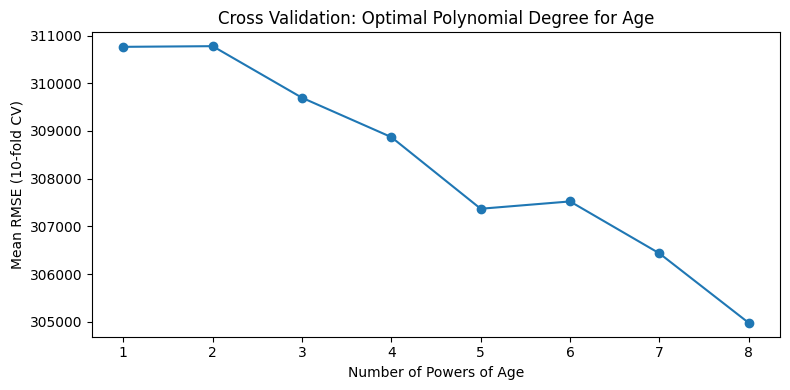

In [20]:
# Plot RMSE vs number of powers
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cv_results['powers'], cv_results['mean_rmse'], marker='o')
ax.set_xlabel('Number of Powers of Age')
ax.set_ylabel('Mean RMSE (10-fold CV)')
ax.set_title('Cross Validation: Optimal Polynomial Degree for Age')
ax.set_xticks(cv_results['powers'])
plt.tight_layout()
plt.show()

## Part 4

Best formula: Price ~ np.power(Age, 1) + np.power(Age, 2) + np.power(Age, 3) + np.power(Age, 4) + np.power(Age, 5) + np.power(Age, 6) + np.power(Age, 7) + np.power(Age, 8)


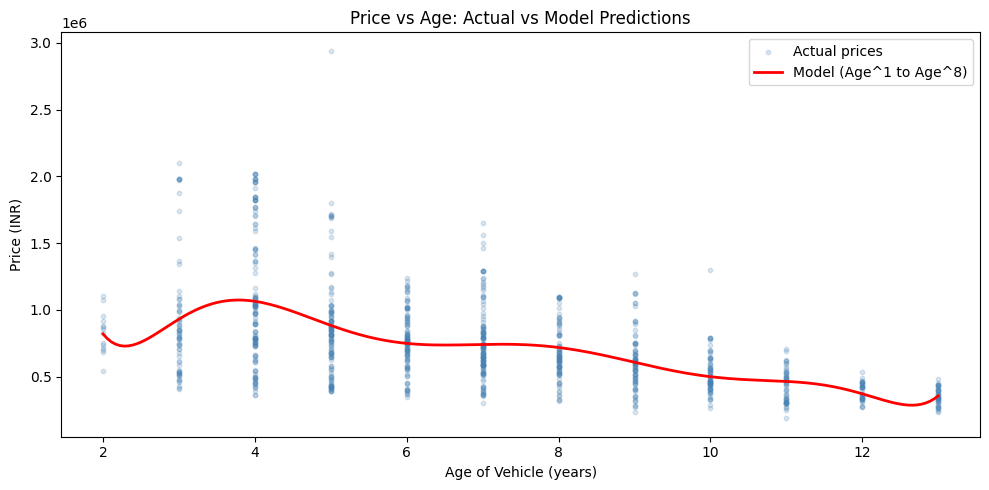

In [21]:
# Fit best model (use the power with lowest CV RMSE)
best_p = int(cv_results.loc[cv_results['mean_rmse'].idxmin(), 'powers'])
best_formula = 'Price ~ ' + ' + '.join([f'np.power(Age, {i})' for i in range(1, best_p+1)])
print(f'Best formula: {best_formula}')

best_model = smf.ols(best_formula, data=df).fit()

# Generate smooth predictions across age range
age_range = pd.DataFrame({'Age': np.linspace(df['Age'].min(), df['Age'].max(), 200)})
age_range['predicted_Price'] = best_model.predict(age_range)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Age'], df['Price'], alpha=0.2, s=10, color='steelblue', label='Actual prices')
ax.plot(age_range['Age'], age_range['predicted_Price'], color='red', linewidth=2, label=f'Model (Age^1 to Age^{best_p})')
ax.set_xlabel('Age of Vehicle (years)')
ax.set_ylabel('Price (INR)')
ax.set_title('Price vs Age: Actual vs Model Predictions')
ax.legend()
plt.tight_layout()
plt.show()

The model partially fits with the general downward trend of older cars being cheaper. It shows that there is a significant drop after age 4-5. However, it fails with the bump at age 3-4. The model shows prices rising from age 2-4, but the data is probably skewed with a lot of expensive cars in the 3-4 year old range in this dataset. Another way it fails is that it doesn't capture the entire variance. The model only predicts the average, so it doesn't show the entire spread.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold

heart = pd.read_csv('/content/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


## Part 1

In [23]:
#1
control_survival   = heart[heart['transplant'] == 'control']['y'].mean()
treatment_survival = heart[heart['transplant'] == 'treatment']['y'].mean()
ate = treatment_survival - control_survival

print(f'(a) Control group survival rate:   {control_survival:.4f} ({control_survival*100:.1f}%)')
print(f'(b) Treatment group survival rate: {treatment_survival:.4f} ({treatment_survival*100:.1f}%)')
print(f'ATE (b - a):                       {ate:.4f} ({ate*100:.1f}%)')

(a) Control group survival rate:   0.1176 (11.8%)
(b) Treatment group survival rate: 0.3478 (34.8%)
ATE (b - a):                       0.2302 (23.0%)


Only 11.8% of the control group (no transplant) survived three years. 34.8% of the treatment group survived three years. The ATE is 0.23, meaning receiving a transplant is associated with a 23 percentage point increase in the probability of surviving three years.

## Part 2

In [24]:
#2
model2 = smf.ols('y ~ C(transplant)', data=heart).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        20:04:59   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [25]:
print('Comparing regression to Part 1:')
print(f'Intercept:           {model2.params["Intercept"]:.4f}')
print(f'Treatment coef:      {model2.params["C(transplant)[T.treatment]"]:.4f}')

Comparing regression to Part 1:
Intercept:           0.1176
Treatment coef:      0.2302


The intercept, 0.1176, is the survival rate of the control group. The treatment coefficient, 0.2302, is the ATE. This confirms that regressing a binary outcome on a single dummy variable perfectly recovers the group means.

## Part 3

In [26]:
#3
model3 = smf.ols('y ~ C(transplant) + age', data=heart).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        20:04:59   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [27]:
print('How did the transplant coefficient change?')
print(f'  Model 2 (no age): {model2.params["C(transplant)[T.treatment]"]:.4f}')
print(f'  Model 3 (with age): {model3.params["C(transplant)[T.treatment]"]:.4f}')
print(f'  Change: {model3.params["C(transplant)[T.treatment]"] - model2.params["C(transplant)[T.treatment]"]:+.4f}')

How did the transplant coefficient change?
  Model 2 (no age): 0.2302
  Model 3 (with age): 0.2647
  Change: +0.0345


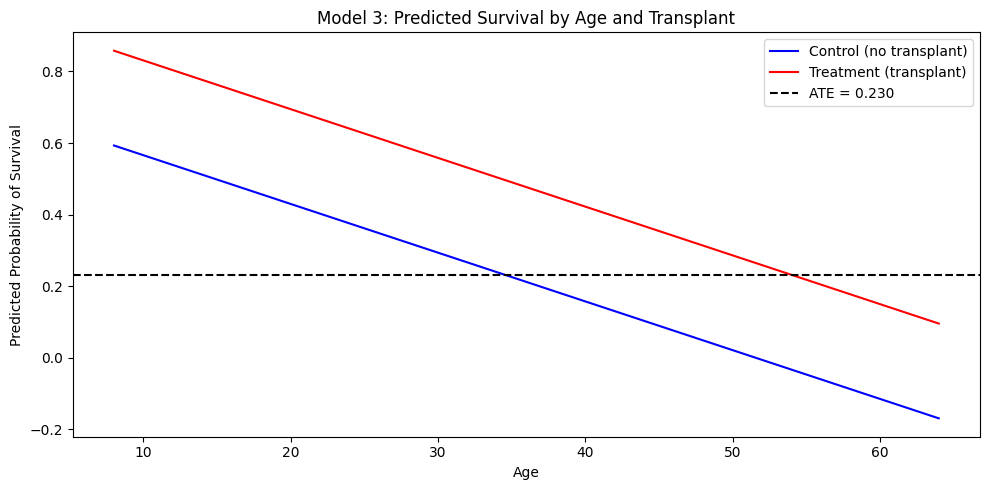

In [28]:
# Plot predicted probability of survival by age
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 200)

pred_control   = pd.DataFrame({'age': age_range, 'transplant': 'control'})
pred_treatment = pd.DataFrame({'age': age_range, 'transplant': 'treatment'})

pred_control['pred']   = model3.predict(pred_control)
pred_treatment['pred'] = model3.predict(pred_treatment)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(age_range, pred_control['pred'],   label='Control (no transplant)', color='blue')
ax.plot(age_range, pred_treatment['pred'], label='Treatment (transplant)',   color='red')
ax.axhline(y=ate, color='black', linestyle='--', label=f'ATE = {ate:.3f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted Probability of Survival')
ax.set_title('Model 3: Predicted Survival by Age and Transplant')
ax.legend()
plt.tight_layout()
plt.show()

The intercept is the predicted survival probability for the baseline transplant group at age 0. The age slope is the change in predicted survival probability associated with a one-year increase in age, holding transplant status fixed. The transplant coefficient is the treatment-control difference holding age fixed
Because age = 0 is not meaningful here, the intercept is mostly a mathematical anchor. The slopes and predicted values across realistic ages matter more.

## Part 4

In [29]:
#4
model4 = smf.ols('y ~ C(transplant) * age', data=heart).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        20:04:59   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

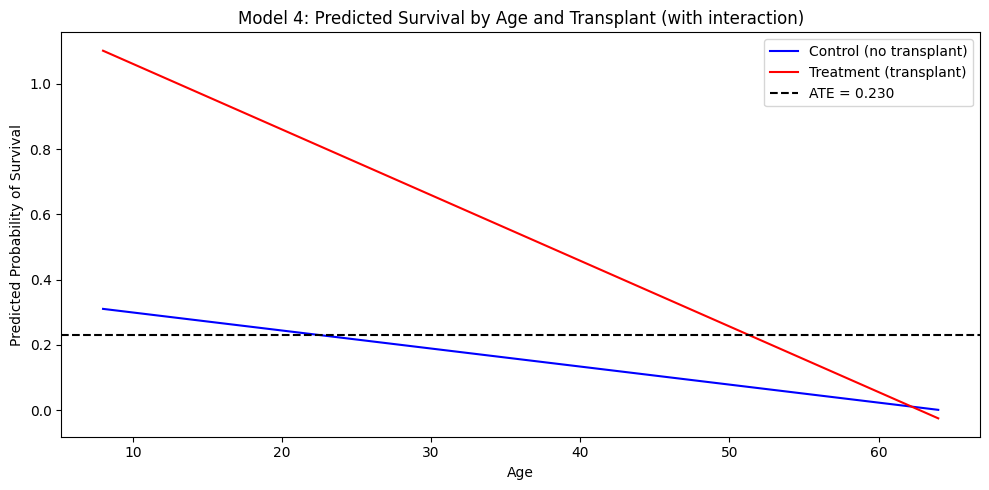

In [30]:
# Plot predicted probability with interaction
pred_control['pred4']   = model4.predict(pred_control)
pred_treatment['pred4'] = model4.predict(pred_treatment)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(age_range, pred_control['pred4'],   label='Control (no transplant)', color='blue')
ax.plot(age_range, pred_treatment['pred4'], label='Treatment (transplant)',   color='red')
ax.axhline(y=ate, color='black', linestyle='--', label=f'ATE = {ate:.3f}')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted Probability of Survival')
ax.set_title('Model 4: Predicted Survival by Age and Transplant (with interaction)')
ax.legend()
plt.tight_layout()
plt.show()

In Model 3, the two lines were parallel, so the transplate benefit was the same at every age. However, in Model 4, the lines are not parallel because the transplant benefit decreases with age. Transplant benefits younger patients more than older patients. For very old patients the lines converge, showing the transplant provides little additional survival benefit.

## Part 5

In [32]:
#5
def rmse_cv(formula, data, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test  = data.iloc[test_idx]
        fit   = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse  = np.sqrt(np.mean((test['y'] - preds)**2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

formulas = [
    'y ~ C(transplant)',
    'y ~ C(transplant) + age',
    'y ~ C(transplant) * age'
]

cv_results = pd.DataFrame([
    {'model': f, 'mean_rmse': rmse_cv(f, heart)[0], 'std_rmse': rmse_cv(f, heart)[1]}
    for f in formulas
]).sort_values('mean_rmse')

print(cv_results.to_string(index=False))

                  model  mean_rmse  std_rmse
y ~ C(transplant) * age   0.412956  0.067735
y ~ C(transplant) + age   0.416697  0.060250
      y ~ C(transplant)   0.436510  0.050276


##Part 6

A concern is that the dataset is so tiny with only 103 patients, so any patterns found may be specific to this sample and not the broader population. Another concern is that using OLS on a binary outcome can produce predicted probabilities outside of 0 and 1, which is logically impossible. The last concern is that a model could systematically disadvantage older patients or other groups if historical treatment patterns reflect inequities.